In [ ]:
import pandas as pd


pickle_file = "/content/drive/MyDrive/NER_Semantics.pkl"
# Later, you can load it back into a DataFrame like this:
df_loaded = pd.read_pickle(pickle_file)
print("DataFrame loaded successfully from pickle file")
df = df_loaded

DataFrame loaded successfully from pickle file


In [ ]:
!python -m spacy download en_core_web_trf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 457.4/457.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.3/236.3 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 735.6/735.6 kB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 111.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!python -m spacy download en_core_web_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 587.7/587.7 MB 2.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy
from spacy.tokens import Span
import pandas as pd

In [ ]:

# If your tag columns are strings, you might need:
# import ast

# Example DataFrame


# Load your spaCy model
nlp = spacy.load("en_core_web_lg")

def build_doc(row):
    text = row["Description"]
    doc = nlp(text)
    entities = []
    # Map DataFrame tag columns to the entity label you want to assign.
    tag_label_map = {
        "Plant Tags": "PLANT",
        "Disease Tags": "DISEASE",
        "Colors Tags": "COLOR",
        "Semantics Tags": "SEMANTIC"
    }

    # Loop over each tag column and create Spans for each tuple.
    for col, label in tag_label_map.items():
        tag_list = row[col]
        # If your tag_list is stored as a string, uncomment the next line:
        # tag_list = ast.literal_eval(row[col])
        for start, end in tag_list:
            # Use char_span to convert character indices to a Span over tokens.
            span = doc.char_span(start, end, label=label, alignment_mode="expand")
            if span is None:
                # This might happen if the character offsets don’t align perfectly with token boundaries.
                print(f"Warning: Could not create span for {label} from char {start} to {end}.")
            else:
                entities.append(span)
    # Set the entities for the doc.
    doc.ents = entities
    return doc

# Build docs for each row in the DataFrame.
docs = [build_doc(row) for idx, row in df.iterrows()]
"""
# Example: print the doc text and its entities.
for doc in docs:
    print("Doc text:", doc.text)
    for ent in doc.ents:
        print(f"Entity: {ent.text} Label: {ent.label_}")
"""

'\n# Example: print the doc text and its entities.\nfor doc in docs:\n    print("Doc text:", doc.text)\n    for ent in doc.ents:\n        print(f"Entity: {ent.text} Label: {ent.label_}")\n'

In [ ]:
len(docs)

15400

In [ ]:
import random
random.shuffle(docs)
train_docs = docs[len(docs) // 5:]
dev_docs = docs[:len(docs) // 5]

In [ ]:
from spacy.tokens import DocBin
# Create and save a collection of training docs
train_docbin = DocBin(docs=train_docs)
train_docbin.to_disk("./train.spacy")
# Create and save a collection of evaluation docs
dev_docbin = DocBin(docs=dev_docs)
dev_docbin.to_disk("./dev.spacy")

In [ ]:
#!python -m spacy init fill-config /content/drive/MyDrive/base_config.cfg /content/drive/MyDrive/config.cfg

In [ ]:


!python -m spacy init config ./config.cfg --lang en --pipeline tok2vec,ner



⚠ To generate a more effective transformer-based config (GPU-only),
install the spacy-transformers package and re-run this command. The config
generated now does not use transformers.
ℹ Generated config template specific for your use case
- Language: en
- Pipeline: ner
- Optimize for: efficiency
- Hardware: CPU
- Transformer: None
✔ Auto-filled config with all values
✔ Saved config
config.cfg
You can now add your data and train your pipeline:
python -m spacy train config.cfg --paths.train ./train.spacy --paths.dev ./dev.spacy


In [ ]:


!python -m spacy train ./config.cfg --output /content/drive/MyDrive/output --paths.train ./train.spacy --paths.dev ./dev.spacy --gpu-id 0



ℹ Saving to output directory: /content/drive/MyDrive/output
ℹ Using GPU: 0

=========================== Initializing pipeline ===========================
✔ Initialized pipeline

============================= Training pipeline =============================
ℹ Pipeline: ['tok2vec', 'ner']
ℹ Initial learn rate: 0.001
E    #       LOSS TOK2VEC  LOSS NER  ENTS_F  ENTS_P  ENTS_R  SCORE 
---  ------  ------------  --------  ------  ------  ------  ------
  0       0          0.00     50.94    2.73    1.50   15.54    0.03
  0     200        466.72   1698.23   88.82   86.62   91.13    0.89
  0     400        763.70    571.48   93.94   91.30   96.74    0.94
  0     600        106.05    463.58   94.95   92.76   97.24    0.95
  0     800        127.85    570.79   94.22   95.12   93.33    0.94
  0    1000         83.79    598.90   95.86   93.22   98.65    0.96
  0    1200        107.09    568.38   95.81   93.42   98.32    0.96
  0    1400        153.73    689.78   97.03   95.39   98.73    0.97
  0  

In [ ]:
!pip install ace_tools

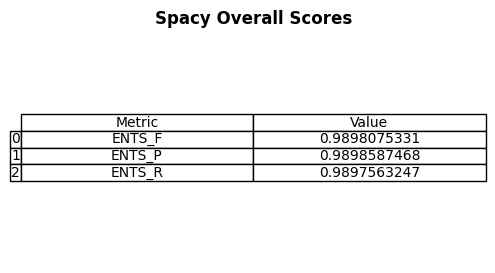

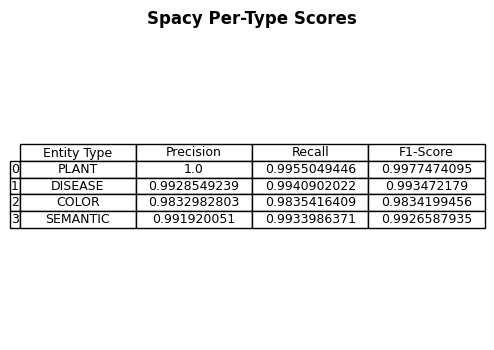

In [ ]:
import pandas as pd
import json

# Load Spacy evaluation metrics JSON file
json_path = "/content/drive/MyDrive/output/model-best/meta.json"
with open(json_path, "r") as f:
    metrics = json.load(f)

import pandas as pd
import json

# JSON data (replace with actual file reading if needed)
json_data = metrics

# Extract overall entity scores
overall_scores = {
    "Metric": ["ENTS_F", "ENTS_P", "ENTS_R"],
    "Value": [
        json_data["performance"]["ents_f"],
        json_data["performance"]["ents_p"],
        json_data["performance"]["ents_r"],
    ]
}

# Extract per-type entity scores
ents_per_type = json_data["performance"]["ents_per_type"]
type_scores = {
    "Entity Type": [],
    "Precision": [],
    "Recall": [],
    "F1-Score": []
}

for entity, scores in ents_per_type.items():
    type_scores["Entity Type"].append(entity)
    type_scores["Precision"].append(scores["p"])
    type_scores["Recall"].append(scores["r"])
    type_scores["F1-Score"].append(scores["f"])

# Create DataFrames
df_overall = pd.DataFrame(overall_scores)
df_types = pd.DataFrame(type_scores)

# Display DataFrames
import matplotlib.pyplot as plt
from pandas.plotting import table

fig, ax = plt.subplots(figsize=(6, 3))
ax.set_title("Spacy Overall Scores", fontsize=12, fontweight="bold")
ax.axis("off")
table(ax, df_overall, loc="center", cellLoc="center")

fig, ax = plt.subplots(figsize=(6, 4))
ax.set_title("Spacy Per-Type Scores", fontsize=12, fontweight="bold")
ax.axis("off")
table(ax, df_types, loc="center", cellLoc="center")

plt.show()



In [ ]:
# Printing per-entity F1 scores
print("\nPer-Entity F1 Scores:")
for entity, scores in ents_per_type.items():
    print(f"{entity}: {scores['f']:.4f}")

# Printing overall model F1 score
print("\nOverall Model F1 Score:")
print(f"ENTS_F: {metrics['performance']['ents_f']:.4f}")

# Printing overall model F1 score
print("\nOverall Model Accuracy:")
print(f"ENTS_F: {metrics['performance']['SCORE']:.4f}")


Per-Entity F1 Scores:
PLANT: 0.9977
DISEASE: 0.9935
COLOR: 0.9834
SEMANTIC: 0.9927

Overall Model F1 Score:
ENTS_F: 0.9898

Overall Model Accuracy:


KeyError: 'SCORE'

In [ ]:
nlp = spacy.load("/content/drive/MyDrive/output/model-best")
doc = nlp("in kiwi plants impacted by puka disease, symptoms manifest as brown or black necrotic spots on the leaves, along with dieback affecting both leaves and branches.")
print(doc.ents)

(kiwi, puka, brown, black, spots)


In [ ]:
nlp.pipe_labels['ner']

['COLOR', 'DISEASE', 'PLANT', 'SEMANTIC']

In [ ]:
doc.ents[0].label_

'PLANT'

In [ ]:
from collections import defaultdict

entities_by_label = defaultdict(list)
for ent in doc.ents:
    entities_by_label[ent.label_].append(ent.text)

print(dict(entities_by_label))


{'PLANT': ['kiwi', 'puka'], 'COLOR': ['brown', 'black'], 'SEMANTIC': ['spots']}


In [ ]:
nlp.pipeline

[('tok2vec', <spacy.pipeline.tok2vec.Tok2Vec at 0x7b42bc0c0050>),
 ('ner', <spacy.pipeline.ner.EntityRecognizer at 0x7b42bba10740>)]